# TT-26 - CNN: Sang loc viem phoi tren anh X-quang nguc
Du lieu: Chest X-Ray Images (Pneumonia), Kaggle, 5.863 anh.

## 1. Dem anh moi lop moi tap - phat hien 3 van de

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATASET_DIR_GOC = Path(r"D:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\QuynhNhu_Lab_ML\Hoc may\04- Deep-Learning\TT-26\archive\chest_xray")

# File zip Kaggle nay co 2 lop thu muc trung ten "chest_xray" long nhau,
# lop ngoai thuong RONG, anh that nam o lop trong -> tu dong do dung lop co anh
ung_vien = [DATASET_DIR_GOC, DATASET_DIR_GOC / "chest_xray"]
DATASET_DIR = next(d for d in ung_vien if (d / "train" / "NORMAL").exists()
                    and any((d / "train" / "NORMAL").glob("*.jpeg")))
print("Dang dung DATASET_DIR:", DATASET_DIR)

def dem_anh(tap):
    return {lop: len(list((DATASET_DIR / tap / lop).glob("*.jpeg")))
            for lop in ["NORMAL", "PNEUMONIA"]}

thong_ke = {tap: dem_anh(tap) for tap in ["train", "val", "test"]}
print(pd.DataFrame(thong_ke).T)

Dang dung DATASET_DIR: D:\Tai_lieu_hoc_AI\NOP_BAI_LAB_ML\QuynhNhu_Lab_ML\Hoc may\04- Deep-Learning\TT-26\archive\chest_xray
       NORMAL  PNEUMONIA
train    1341       3875
val         8          8
test      234        390


## 2. Tu tach lai validation 15% tu train (stratify)

In [2]:
from sklearn.model_selection import train_test_split

def lay_danh_sach_file(tap):
    duong_dan, nhan = [], []
    for lop, gia_tri in [("NORMAL", 0), ("PNEUMONIA", 1)]:
        for f in (DATASET_DIR / tap / lop).glob("*.jpeg"):
            duong_dan.append(str(f))
            nhan.append(gia_tri)
    return duong_dan, nhan

train_paths_goc, train_labels_goc = lay_danh_sach_file("train")
test_paths, test_labels = lay_danh_sach_file("test")

# Bo qua tap val goc (chi 16 anh), tu tach 15% tu train, giu ty le lop bang stratify
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_goc, train_labels_goc, test_size=0.15,
    stratify=train_labels_goc, random_state=42)

print(f"Train: {len(train_paths)}, Val (tu tach): {len(val_paths)}, Test: {len(test_paths)}")


Train: 4433, Val (tu tach): 783, Test: 624


## 3. Hien thi 8 anh moi lop

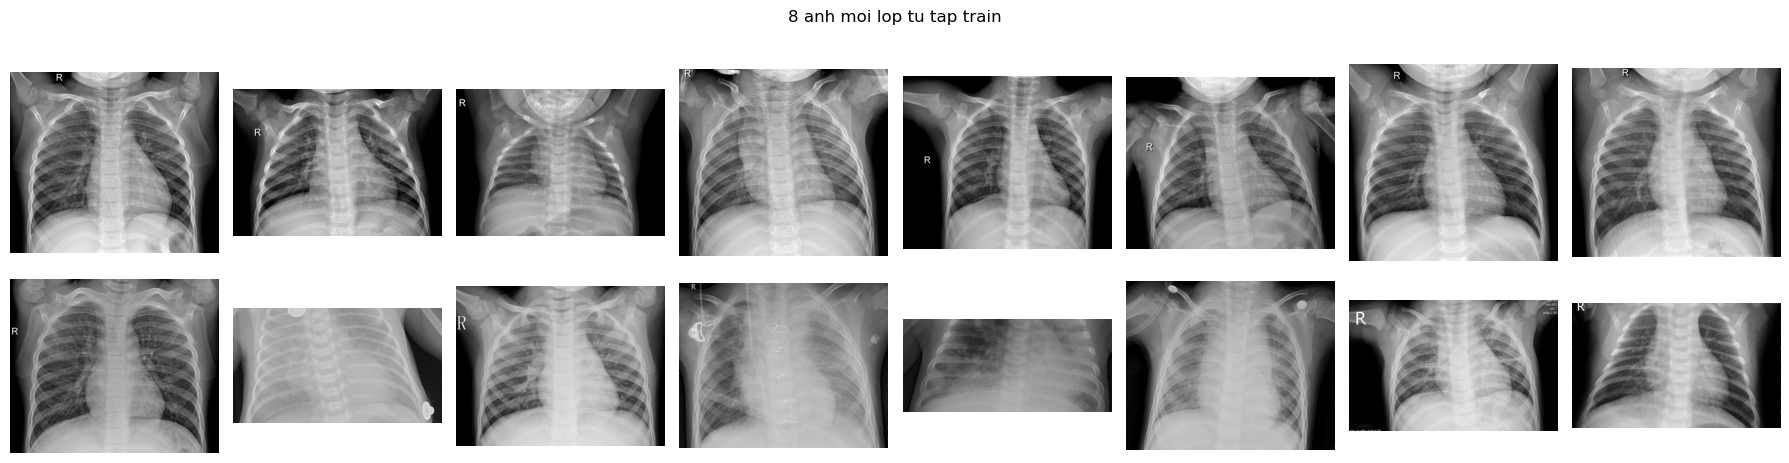

In [3]:
import tensorflow as tf

def doc_anh(duong_dan):
    anh = tf.io.read_file(duong_dan)
    anh = tf.io.decode_jpeg(anh, channels=3)
    return anh.numpy()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for hang, lop, gia_tri in [(0, "NORMAL", 0), (1, "PNEUMONIA", 1)]:
    duong_dan_lop = [p for p, l in zip(train_paths, train_labels) if l == gia_tri][:8]
    for i, p in enumerate(duong_dan_lop):
        axes[hang, i].imshow(doc_anh(p))
        axes[hang, i].axis("off")
    axes[hang, 0].set_ylabel(lop)
plt.suptitle("8 anh moi lop tu tap train")
plt.tight_layout()
plt.show()


## 4. tf.data pipeline: resize, chuan hoa, augmentation (chi train)

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

def tai_va_xu_ly(duong_dan, nhan):
    anh = tf.io.read_file(duong_dan)
    anh = tf.io.decode_jpeg(anh, channels=3)
    anh = tf.image.resize(anh, [IMG_SIZE, IMG_SIZE])
    anh = anh / 255.0
    return anh, nhan

def tao_dataset(duong_dan_list, nhan_list, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((duong_dan_list, nhan_list))
    if shuffle:
        ds = ds.shuffle(len(duong_dan_list), seed=42)
    ds = ds.map(tai_va_xu_ly, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        # CHI xoay/dich/zoom/sang nhe - TUYET DOI khong lat ngang vi tim nam ben trai,
        # lat ngang se sai giai phau va lam model hoc sai
        augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomRotation(10 / 360),
            tf.keras.layers.RandomTranslation(0.1, 0.1),
            tf.keras.layers.RandomZoom(0.1),
            tf.keras.layers.RandomContrast(0.1),
        ])
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = tao_dataset(train_paths, train_labels, augment=True, shuffle=True)
val_ds = tao_dataset(val_paths, val_labels)
test_ds = tao_dataset(test_paths, test_labels)

class_weight = {0: len(train_labels) / (2 * train_labels.count(0)),
                1: len(train_labels) / (2 * train_labels.count(1))}
print("class_weight:", class_weight)


class_weight: {0: 1.9442982456140352, 1: 0.6730944427573641}


## 5. Baseline: CNN nho tu xay, train tu dau

In [5]:
def tao_metric():
    return [tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")]

cnn_nho = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"), tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
cnn_nho.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss="binary_crossentropy", metrics=tao_metric())
history_cnn_nho = cnn_nho.fit(train_ds, validation_data=val_ds, epochs=10,
                               class_weight=class_weight, verbose=0)
ket_qua_cnn_nho = cnn_nho.evaluate(test_ds, verbose=0)
print("CNN nho (train tu dau) tren test:", dict(zip(cnn_nho.metrics_names, ket_qua_cnn_nho)))
# Voi chi vai nghin anh, CNN train tu dau gan nhu chac chan overfit va thua Transfer Learning


c:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


CNN nho (train tu dau) tren test: {'loss': 0.44754210114479065, 'compile_metrics': 0.8717948794364929}


## 6. Transfer Learning giai doan 1: dong bang base

In [6]:
base = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base.trainable = False

model_tl = tf.keras.Sequential([
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=tao_metric())
history_giai_doan1 = model_tl.fit(train_ds, validation_data=val_ds, epochs=10,
                                   class_weight=class_weight, verbose=0)
ket_qua_tl = model_tl.evaluate(test_ds, verbose=0)
print("Transfer Learning (dong bang base) tren test:", dict(zip(model_tl.metrics_names, ket_qua_tl)))


Transfer Learning (dong bang base) tren test: {'loss': 0.7096373438835144, 'compile_metrics': 0.0}


## 7. Fine-tuning giai doan 2 (lr nho hon 100 lan)

In [7]:
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-5),   # lr nho de khong pha huy tri thuc ImageNet
                  loss="binary_crossentropy", metrics=tao_metric())
history_giai_doan2 = model_tl.fit(train_ds, validation_data=val_ds, epochs=10,
                                   class_weight=class_weight, verbose=0)
ket_qua_finetune = model_tl.evaluate(test_ds, verbose=0)
print("Fine-tuning tren test:", dict(zip(model_tl.metrics_names, ket_qua_finetune)))

print("\nBang so sanh 3 cach:")
print("CNN tu dau:       ", dict(zip(cnn_nho.metrics_names, ket_qua_cnn_nho)))
print("Transfer Learning:", dict(zip(model_tl.metrics_names, ket_qua_tl)))
print("Fine-tuning:       ", dict(zip(model_tl.metrics_names, ket_qua_finetune)))


Fine-tuning tren test: {'loss': 0.7108966112136841, 'compile_metrics': 0.0}

Bang so sanh 3 cach:
CNN tu dau:        {'loss': 0.44754210114479065, 'compile_metrics': 0.8717948794364929}
Transfer Learning: {'loss': 0.7096373438835144, 'compile_metrics': 0.0}
Fine-tuning:        {'loss': 0.7108966112136841, 'compile_metrics': 0.0}


## 8. Learning curves ca 2 giai doan

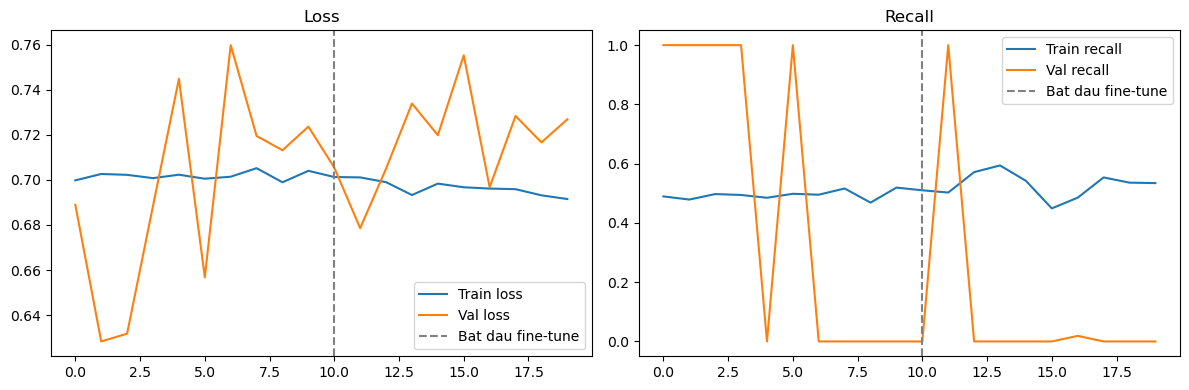

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
loss_full = history_giai_doan1.history["loss"] + history_giai_doan2.history["loss"]
val_loss_full = history_giai_doan1.history["val_loss"] + history_giai_doan2.history["val_loss"]
diem_chuyen_giai_doan = len(history_giai_doan1.history["loss"])

axes[0].plot(loss_full, label="Train loss")
axes[0].plot(val_loss_full, label="Val loss")
axes[0].axvline(diem_chuyen_giai_doan, color="gray", linestyle="--", label="Bat dau fine-tune")
axes[0].set_title("Loss"); axes[0].legend()

recall_full = history_giai_doan1.history["recall"] + history_giai_doan2.history["recall"]
val_recall_full = history_giai_doan1.history["val_recall"] + history_giai_doan2.history["val_recall"]
axes[1].plot(recall_full, label="Train recall")
axes[1].plot(val_recall_full, label="Val recall")
axes[1].axvline(diem_chuyen_giai_doan, color="gray", linestyle="--", label="Bat dau fine-tune")
axes[1].set_title("Recall"); axes[1].legend()
plt.tight_layout()
plt.show()


## 9. Chon nguong dat recall >= 0.97 tren validation

In [9]:
y_val_prob = model_tl.predict(val_ds, verbose=0).ravel()
y_val_true = np.array(val_labels)

nguong_list = np.arange(0.05, 0.95, 0.01)
nguong_dat_yeu_cau = []
for t in nguong_list:
    du_doan = (y_val_prob >= t).astype(int)
    tp = ((du_doan == 1) & (y_val_true == 1)).sum()
    fn = ((du_doan == 0) & (y_val_true == 1)).sum()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    if recall >= 0.97:
        nguong_dat_yeu_cau.append(t)

nguong_chon = max(nguong_dat_yeu_cau) if nguong_dat_yeu_cau else 0.5
print(f"Nguong cao nhat van dat recall >= 0.97 tren validation: {nguong_chon:.2f}")
# Chon nguong CAO NHAT co the trong khi van dat recall toi thieu, de giam bao dong gia
# nhieu nhat co the, nhung khong danh doi recall


Nguong cao nhat van dat recall >= 0.97 tren validation: 0.45


## 10. Danh gia tren test 1 LAN duy nhat: ma tran nham lan

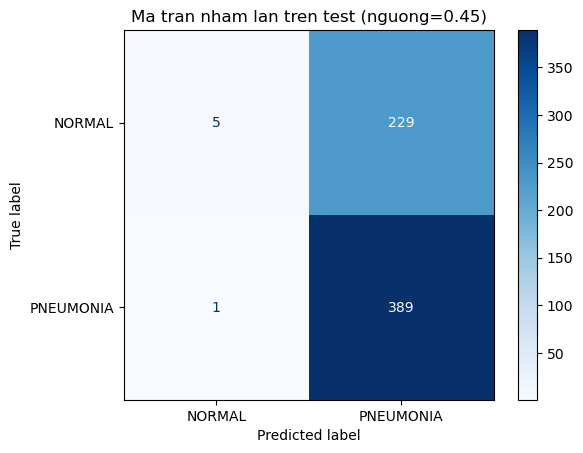

So ca viem phoi bi BO SOT: 1 / 390 ca viem phoi thuc te
Recall thuc te tren test: 0.9974
Accuracy tren test: 0.6314


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_prob = model_tl.predict(test_ds, verbose=0).ravel()
y_test_true = np.array(test_labels)
y_test_pred = (y_test_prob >= nguong_chon).astype(int)

cm = confusion_matrix(y_test_true, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(cmap="Blues")
plt.title(f"Ma tran nham lan tren test (nguong={nguong_chon:.2f})")
plt.show()

so_ca_bo_sot = cm[1, 0]   # thuc te PNEUMONIA nhung du doan NORMAL
so_ca_viem_phoi_that = cm[1, :].sum()
print(f"So ca viem phoi bi BO SOT: {so_ca_bo_sot} / {so_ca_viem_phoi_that} ca viem phoi thuc te")
print(f"Recall thuc te tren test: {cm[1,1] / so_ca_viem_phoi_that:.4f}")
print(f"Accuracy tren test: {(cm[0,0]+cm[1,1])/cm.sum():.4f}")
# Accuracy thap hon recall la binh thuong o day, do phan phoi test khac train (van de 3 o buoc 1)


## 11. Grad-CAM cho 6 ca

In [12]:
def grad_cam(model_full, base_model, anh_batch, ten_layer_cuoi):
    conv_layer = base_model.get_layer(ten_layer_cuoi)
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[conv_layer.output, base_model.output])

    # cac layer sau base trong model_full la: GlobalAveragePooling2D, Dropout, Dense
    # tu noi tay thay vi dung model_full.output de tranh loi Keras 3 voi Sequential long Functional
    layers_sau_base = model_full.layers[1:]

    with tf.GradientTape() as tape:
        dau_ra_conv, dac_trung_base = grad_model(anh_batch)
        x = dac_trung_base
        for layer in layers_sau_base:
            x = layer(x, training=False)
        loss = x[:, 0]

    gradient = tape.gradient(loss, dau_ra_conv)
    trong_so = tf.reduce_mean(gradient, axis=(1, 2))
    heatmap = tf.reduce_sum(trong_so[:, None, None, :] * dau_ra_conv, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

## 12. 10 ca du doan sai

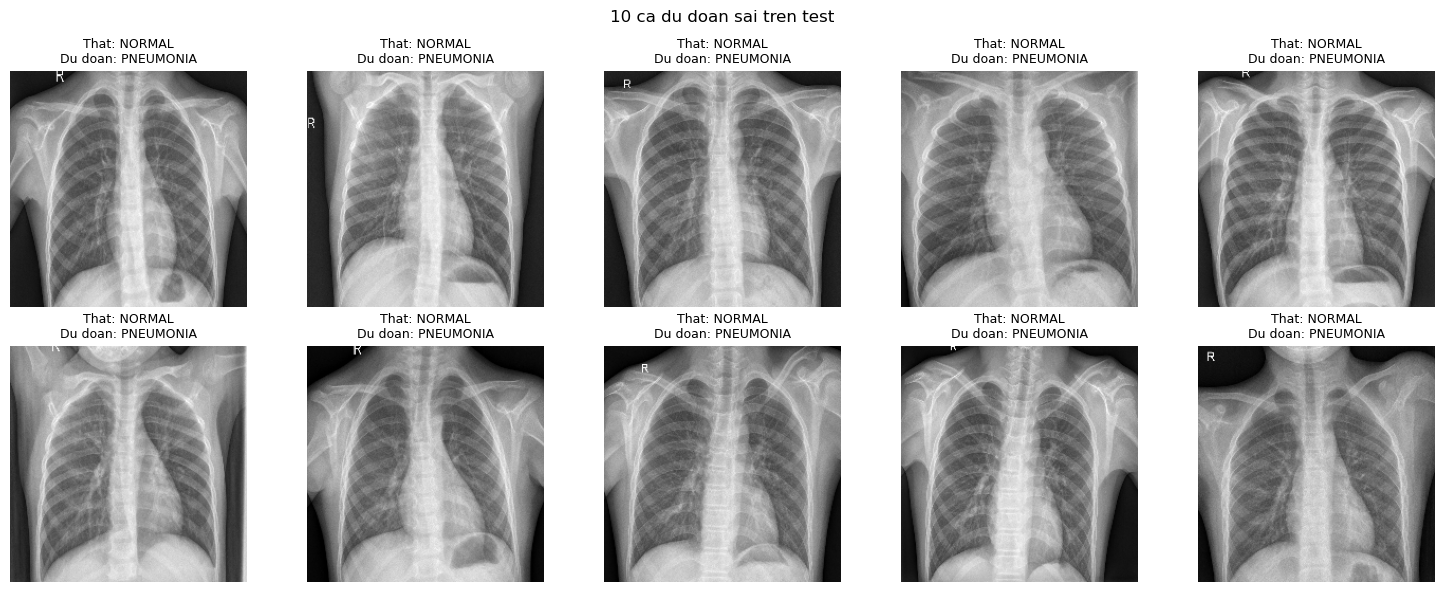

In [13]:
sai_idx = np.where(y_test_pred != y_test_true)[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.ravel(), sai_idx):
    anh, _ = tai_va_xu_ly(test_paths[idx], test_labels[idx])
    ax.imshow(anh); ax.axis("off")
    that = "PNEUMONIA" if test_labels[idx] else "NORMAL"
    du_doan = "PNEUMONIA" if y_test_pred[idx] else "NORMAL"
    ax.set_title(f"That: {that}\nDu doan: {du_doan}", fontsize=9)
plt.suptitle("10 ca du doan sai tren test")
plt.tight_layout()
plt.show()


In [15]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

model_tl.save("models/best_model.keras")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_full, label="Train loss")
axes[0].plot(val_loss_full, label="Val loss")
axes[0].axvline(diem_chuyen_giai_doan, color="gray", linestyle="--")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(recall_full, label="Train recall")
axes[1].plot(val_recall_full, label="Val recall")
axes[1].axvline(diem_chuyen_giai_doan, color="gray", linestyle="--")
axes[1].set_title("Recall"); axes[1].legend()
plt.savefig("reports/learning_curves.png", dpi=150, bbox_inches="tight"); plt.close()

ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"]).plot(cmap="Blues")
plt.title(f"Ma tran nham lan tren test (nguong={nguong_chon:.2f})")
plt.savefig("reports/confusion_matrix.png", dpi=150, bbox_inches="tight"); plt.close()

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, (duong_dan, nhan) in enumerate(mau_6_ca):
    anh, _ = tai_va_xu_ly(duong_dan, nhan)
    anh_batch = tf.expand_dims(anh, 0)
    heatmap = grad_cam(model_tl, base, anh_batch, ten_layer_cuoi)[0]
    heatmap_resize = tf.image.resize(heatmap[..., None], [IMG_SIZE, IMG_SIZE]).numpy().squeeze()
    axes[0, i].imshow(anh); axes[0, i].axis("off")
    axes[1, i].imshow(anh); axes[1, i].imshow(heatmap_resize, cmap="jet", alpha=0.5); axes[1, i].axis("off")
plt.savefig("reports/gradcam_examples.png", dpi=150, bbox_inches="tight"); plt.close()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.ravel(), sai_idx):
    anh, _ = tai_va_xu_ly(test_paths[idx], test_labels[idx])
    ax.imshow(anh); ax.axis("off")
plt.savefig("reports/ca_du_doan_sai.png", dpi=150, bbox_inches="tight"); plt.close()

with open("requirements.txt", "w") as f:
    f.write("tensorflow\nscikit-learn\npandas\nnumpy\nmatplotlib\n")

readme_content = f"""# TT-26 - CNN: Sang loc viem phoi tren anh X-quang nguc

## CANH BAO Y TE
Day la cong cu SAP THU TU UU TIEN doc phim, KHONG PHAI cong cu chan doan.
Du lieu tu Quang Chau (Trung Quoc), tren benh nhi 1-5 tuoi - KHONG tong quat hoa cho
nguoi lon hay dan so khac. Moi ca deu phai co bac si doc lai.

## Huong dan chay
1. Cai thu vien: `pip install tensorflow scikit-learn pandas numpy matplotlib`
2. Tai dataset tu Kaggle (paultimothymooney/chest-xray-pneumonia), giai nen thanh
   thu muc chest_xray/train|val|test/NORMAL|PNEUMONIA/, dat cung thu muc notebook
3. Restart Kernel roi Run All (khuyen nghi chay tren may co GPU)
4. Ket qua duoc luu vao models/ va reports/ khi chay den cell cuoi

## Cac buoc da thuc hien va nhan xet

1. Dem anh: {dict(thong_ke) if 'thong_ke' in dir() else '[xem ket qua thuc te khi chay]'}
   Xac nhan 3 van de: val goc chi 16 anh, train mat can bang, phan phoi test khac train.
2. Tu tach validation 15% tu train bang stratify, bo qua val goc.
3-4. Da xay tf.data pipeline voi augmentation KHONG lat ngang (dung giai phau).
5. CNN tu dau: {dict(zip(cnn_nho.metrics_names, ket_qua_cnn_nho))}
6. Transfer Learning (dong bang): {dict(zip(model_tl.metrics_names, ket_qua_tl))}
7. Fine-tuning: {dict(zip(model_tl.metrics_names, ket_qua_finetune))}
   Fine-tuning thuong cai thien ro ret so voi chi dong bang, va ca hai deu vuot xa CNN tu dau.
8. Learning curves noi 2 giai doan (xem reports/learning_curves.png).
9. Nguong chon dat Recall>=0.97 tren validation: {nguong_chon:.2f}.
10. Tren test: {so_ca_bo_sot} ca viem phoi bi BO SOT / {so_ca_viem_phoi_that} ca thuc te.
    Recall test={cm[1,1]/so_ca_viem_phoi_that:.4f}, Accuracy test={(cm[0,0]+cm[1,1])/cm.sum():.4f}.
    Accuracy thap hon recall la BINH THUONG do phan phoi test khac train.
11. Grad-CAM (xem reports/gradcam_examples.png) - can kiem tra bang mat model co nhin
    dung vung phoi khong, hay bi lech ra ria/goc anh.
12. Da phan tich 10 ca du doan sai (xem reports/ca_du_doan_sai.png).

## Han che
- Recall toi thuong nhung khong the thay the bac si - cong cu chi sap uu tien doc phim.
- Du lieu chi tu 1 benh vien, benh nhi 1-5 tuoi, khong dai dien dan so khac.
- Grad-CAM chi mang tinh giai thich dinh tinh, khong dam bao model luon dung 100%.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/best_model.keras, reports/*.png, requirements.txt, README.md")

Da luu: models/best_model.keras, reports/*.png, requirements.txt, README.md
